In [ ]:
# Para correr en Colab

%pip install roboticstoolbox-python

%pip install numpy==1.26.4 --force-reinstall



# Nota importante: da error porque un montón de bibliotecas de Colab dependen de numpy 2,

# pero como no se utilizan no importa.

#

# Cuando termina de ejecutarse la celda, pide reiniciar el kernel (aparece un botón bien evidente)

# Luego de reiniciar correr las celdas siguientes


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 14.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 62.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.7/114.7 MB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.5/193.5 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 7.4 MB/s eta 0:00

<>:89: SyntaxWarning: invalid escape sequence '\p'
<>:89: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_16775/902149446.py:89: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Mapa de Velocidades del IRB 140 (Trayectoria Y = $\pm 100$mm)', fontsize=14)


Calculando cinemática inversa y velocidades. Esto puede tomar unos segundos...
¡Cálculo finalizado! Generando gráfico...


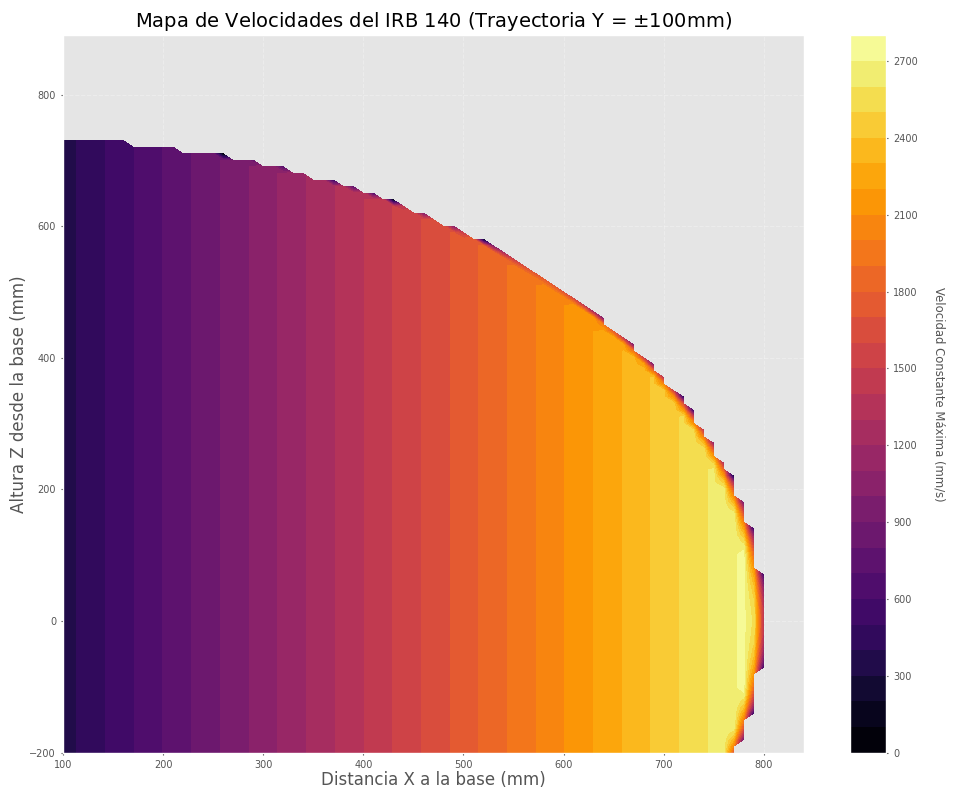

--- RESULTADO ÓPTIMO ---
La trayectoria más rápida está en: X=780 mm, Z=0 mm
Velocidad constante alcanzable: 2723.27 mm/s


In [ ]:
import numpy as np
import roboticstoolbox as rtb
from spatialmath import SE3
import matplotlib.pyplot as plt

# 1. Definición del robot (en mm) según tu configuración
irb140 = rtb.DHRobot(
    [
        rtb.RevoluteDH(alpha=-np.pi/2, a=70),
        rtb.RevoluteDH(a=360),
        rtb.RevoluteDH(alpha=np.pi/2),
        rtb.RevoluteDH(d=380, alpha=-np.pi/2),
    ], name="IRB140_Posicion")

# Límites de velocidad articular para los 4 motores activos en rad/s.
# (Ajusta estos valores si tienes los exactos del datasheet)
limites_deg = np.array([200, 200, 260, 360])
qdot_max = np.deg2rad(limites_deg)

# 2. Definir las cuadrículas (en mm)
# Usamos pasos de 25mm. Si tu PC tarda mucho, súbelo a 50mm para una prueba rápida.
x_range = np.arange(100, 850, 10)
z_range = np.arange(-200, 900, 10)

# Imprimir los rangos para ver la grilla definida
print("X-range de la grilla:", x_range)
print("Z-range de la grilla:", z_range)

# Puntos de la trayectoria: de y = -100mm a y = +100mm
y_points = np.linspace(-100, 100, 10)

# Vector de dirección: Velocidad lineal pura en Y (v_x=0, v_y=1, v_z=0)
v_dir = np.array([0, 1, 0])

# Matriz para guardar los datos del mapa de calor (iniciada con NaN para ignorar fallos)
heatmap_data = np.full((len(z_range), len(x_range)), np.nan)

print("Calculando cinemática inversa y velocidades. Esto puede tomar unos segundos...")

# 3. Bucle de exploración
for i, z in enumerate(z_range):
    for j, x in enumerate(x_range):
        velocidad_minima_linea = np.inf

        # Semilla inicial
        q_guess = np.zeros(4)
        trayectoria_valida = True

        for y in y_points:
            T_deseada = SE3(x, y, z)

            # Paso A: IK numérica.
            # mask=[1,1,1,0,0,0] le dice al solver: "Solo importa X, Y, Z. Ignora la rotación"
            sol = irb140.ikine_LM(T_deseada, q0=q_guess, mask=[1, 1, 1, 0, 0, 0])

            if not sol.success:
                trayectoria_valida = False
                break

            q_guess = sol.q

            # Paso B: Jacobiano (6 filas x 4 columnas)
            J = irb140.jacob0(sol.q)
            # Como solo nos importa la traslación, extraemos la mitad superior (3x4)
            J_pos = J[:3, :]

            # Paso C: Límite de velocidad
            # qdot = pinv(J_pos) * v_dir
            qdot_unitario = np.linalg.pinv(J_pos) @ v_dir

            esfuerzo = np.abs(qdot_unitario) / qdot_max
            v_max_punto = 1.0 / np.max(esfuerzo) # Resultado en mm/s

            if v_max_punto < velocidad_minima_linea:
                velocidad_minima_linea = v_max_punto

        # Guardamos el resultado en la matriz para el gráfico
        if trayectoria_valida:
            heatmap_data[i, j] = velocidad_minima_linea

# 4. Generación de Gráficos (Mapa de Calor)
print("¡Cálculo finalizado! Generando gráfico...")

plt.figure(figsize=(10, 8))
X, Z = np.meshgrid(x_range, z_range)

# contourf crea un mapa topográfico de calor relleno
cp = plt.contourf(X, Z, heatmap_data, levels=30, cmap='inferno')
cbar = plt.colorbar(cp)
cbar.set_label('Velocidad Constante Máxima (mm/s)', rotation=270, labelpad=20)

# Configuraciones visuales del gráfico
plt.title('Mapa de Velocidades del IRB 140 (Trayectoria Y = $\pm 100$mm)', fontsize=14)
plt.xlabel('Distancia X a la base (mm)', fontsize=12)
plt.ylabel('Altura Z desde la base (mm)', fontsize=12)
plt.grid(color='white', linestyle='--', alpha=0.3)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# Encontrar el punto exacto con mayor velocidad
max_vel = np.nanmax(heatmap_data)
idx_z, idx_x = np.where(heatmap_data == max_vel)
mejor_x = x_range[idx_x[0]]
mejor_z = z_range[idx_z[0]]

print(f"--- RESULTADO ÓPTIMO ---")
print(f"La trayectoria más rápida está en: X={mejor_x} mm, Z={mejor_z} mm")
print(f"Velocidad constante alcanzable: {max_vel:.2f} mm/s")

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x_range = np.arange(100, 850, 10)
z_range = np.arange(-200, 900, 10)

plt.figure(figsize=(10, 8))
plt.scatter(X, Z, s=10, c='blue', alpha=0.5)
plt.title('Puntos de la Grilla XZ para el Mapa de Velocidades')
plt.xlabel('Distancia X a la base (mm)')
plt.ylabel('Altura Z desde la base (mm)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

NameError: name 'X' is not defined

<Figure size 1000x800 with 0 Axes>

In [5]:
import numpy as np
import roboticstoolbox as rtb
from spatialmath import SE3
from scipy.optimize import differential_evolution

# 1. Definición del robot (en mm)
irb140 = rtb.DHRobot(
    [
        rtb.RevoluteDH(alpha=-np.pi/2, a=70),
        rtb.RevoluteDH(a=360),
        rtb.RevoluteDH(alpha=np.pi/2),
        rtb.RevoluteDH(d=380, alpha=-np.pi/2),
    ], name="IRB140_Posicion")

# Límites de velocidad articular (rad/s)
limites_deg = np.array([200, 200, 260, 360])
qdot_max = np.deg2rad(limites_deg)

# Parámetros de la trayectoria
y_points = np.linspace(-100, 100, 10)
v_dir = np.array([0, 1, 0])

# 2. Definición del FUNCIONAL (Función de Costo)
def funcion_objetivo(p):
    """
    Recibe un vector p = [X, Z] y devuelve el costo asociado.
    Como scipy.optimize busca MINIMIZAR, vamos a devolver
    el NEGATIVO de la velocidad máxima posible.
    Minimizar (-velocidad) es matemáticamente lo mismo que Maximizar (velocidad).
    """
    x, z = p
    velocidad_minima_linea = np.inf
    q_guess = np.zeros(4)

    for y in y_points:
        T_deseada = SE3(x, y, z)

        # Máscara para ignorar orientación
        sol = irb140.ikine_LM(T_deseada, q0=q_guess, mask=[1, 1, 1, 0, 0, 0])

        if not sol.success:
            # PENALIZACIÓN EXTREMA: Si el punto está fuera del espacio de trabajo
            # o en una singularidad que el solver no puede resolver,
            # devolvemos un costo altísimo para que el optimizador "huya" de acá.
            return 1e6

        q_guess = sol.q
        J_pos = irb140.jacob0(sol.q)[:3, :]

        qdot_unitario = np.linalg.pinv(J_pos) @ v_dir
        esfuerzo = np.abs(qdot_unitario) / qdot_max
        v_max_punto = 1.0 / np.max(esfuerzo)

        if v_max_punto < velocidad_minima_linea:
            velocidad_minima_linea = v_max_punto

    # Retornamos el negativo de la velocidad para que el solver lo minimice
    return -velocidad_minima_linea


# 3. Configuración del Optimizador Numérico
# Le decimos en qué rango buscar (Bounds): X entre 100 y 850, Z entre -200 y 900
limites = [(100, 850), (-200, 900)]

print("Iniciando optimización numérica (Evolución Diferencial)...")
print("El algoritmo está 'caminando' por el espacio buscando el óptimo...")

# Ejecutamos el solver
resultado = differential_evolution(
    funcion_objetivo,
    bounds=limites,
    disp=True,       # Muestra el progreso iteración a iteración
    tol=0.01,        # Tolerancia para considerar que convergió
    popsize=10       # Tamaño de la población (equilibrio entre velocidad y precisión)
)

# 4. Procesamiento del Resultado
if resultado.success:
    mejor_x = resultado.x[0]
    mejor_z = resultado.x[1]

    # Recuperamos el valor real de la velocidad (le sacamos el negativo)
    mejor_velocidad = -resultado.fun

    print("\n--- ¡OPTIMIZACIÓN EXITOSA! ---")
    print(f"El optimizador numérico convergió en la posición:")
    print(f"X = {mejor_x:.2f} mm")
    print(f"Z = {mejor_z:.2f} mm")
    print(f"Velocidad constante máxima: {mejor_velocidad:.2f} mm/s")
    print(f"Cantidad de evaluaciones realizadas: {resultado.nfev}")
else:
    print("\nEl optimizador falló en encontrar una solución.")
    print(resultado.message)

ModuleNotFoundError: No module named 'roboticstoolbox'

<>:78: SyntaxWarning: invalid escape sequence '\p'
<>:78: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_16775/1201335925.py:78: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Mapa de Velocidades del IRB 140 (Trayectoria Vertical Z = $\pm 100$mm)', fontsize=14)


Calculando trayectorias verticales. Esto puede tomar unos segundos...
¡Cálculo finalizado! Generando gráfico...


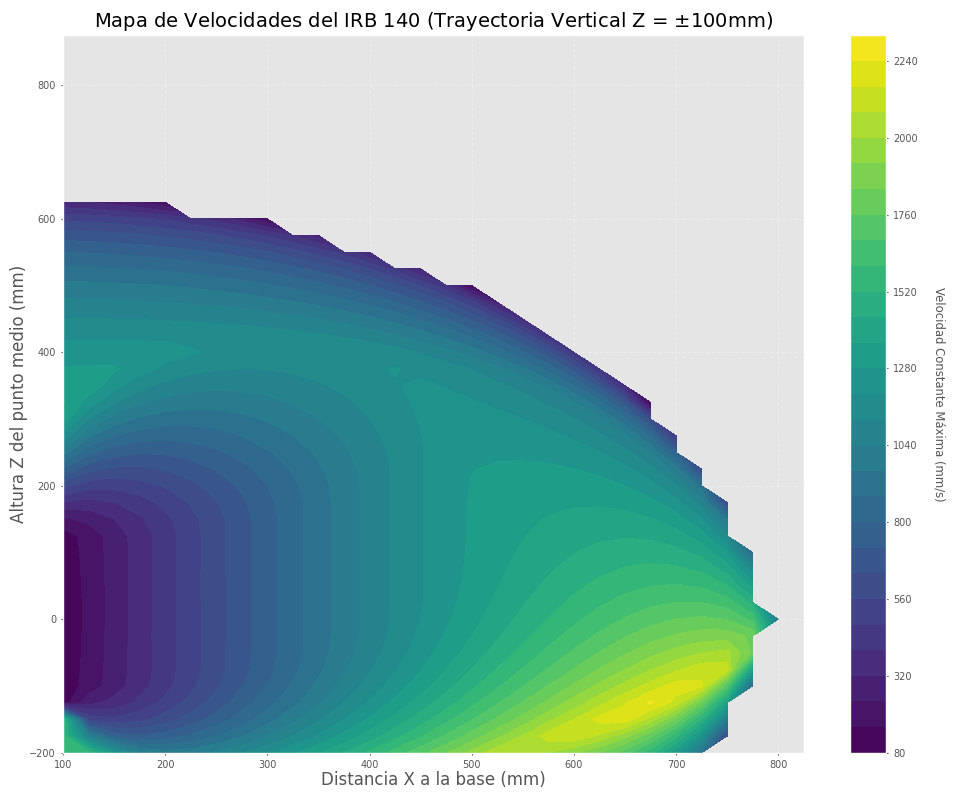

--- RESULTADO ÓPTIMO VERTICAL ---
El punto medio más rápido está en: X=675 mm, Z=-125 mm
Velocidad constante alcanzable: 2253.43 mm/s


In [ ]:
import numpy as np
import roboticstoolbox as rtb
from spatialmath import SE3
import matplotlib.pyplot as plt

# 1. Definición del robot (en mm)
irb140 = rtb.DHRobot(
    [
        rtb.RevoluteDH(alpha=-np.pi/2, a=70),
        rtb.RevoluteDH(a=360),
        rtb.RevoluteDH(alpha=np.pi/2),
        rtb.RevoluteDH(d=380, alpha=-np.pi/2),
    ], name="IRB140_Posicion")

# Límites de velocidad articular (rad/s)
limites_deg = np.array([200, 200, 260, 360])
qdot_max = np.deg2rad(limites_deg)

# 2. Definir las cuadrículas (Puntos medios de la recta)
x_range = np.arange(100, 850, 25)
z_range = np.arange(-200, 900, 25)

# Offsets para la trayectoria vertical: de -100mm a +100mm respecto al centro
z_offsets = np.linspace(-100, 100, 10)

# Vector de dirección: Velocidad lineal pura en Z (v_x=0, v_y=0, v_z=1)
v_dir = np.array([0, 0, 1])

# Matriz para guardar los datos
heatmap_data = np.full((len(z_range), len(x_range)), np.nan)

print("Calculando trayectorias verticales. Esto puede tomar unos segundos...")

# 3. Bucle de exploración
for i, z_mid in enumerate(z_range):
    for j, x_mid in enumerate(x_range):
        velocidad_minima_linea = np.inf

        q_guess = np.zeros(4)
        trayectoria_valida = True

        # Evaluamos los puntos a lo largo de la línea vertical
        for z_off in z_offsets:
            z_actual = z_mid + z_off
            # Mantemos Y=0 y movemos Z
            T_deseada = SE3(x_mid, 0, z_actual)

            sol = irb140.ikine_LM(T_deseada, q0=q_guess, mask=[1, 1, 1, 0, 0, 0])

            if not sol.success:
                trayectoria_valida = False
                break

            q_guess = sol.q
            J_pos = irb140.jacob0(sol.q)[:3, :]

            # Calculamos esfuerzo usando el nuevo v_dir (Z puro)
            qdot_unitario = np.linalg.pinv(J_pos) @ v_dir
            esfuerzo = np.abs(qdot_unitario) / qdot_max
            v_max_punto = 1.0 / np.max(esfuerzo)

            if v_max_punto < velocidad_minima_linea:
                velocidad_minima_linea = v_max_punto

        if trayectoria_valida:
            heatmap_data[i, j] = velocidad_minima_linea

# 4. Generación de Gráficos (Mapa de Calor)
print("¡Cálculo finalizado! Generando gráfico...")

plt.figure(figsize=(10, 8))
X, Z = np.meshgrid(x_range, z_range)

cp = plt.contourf(X, Z, heatmap_data, levels=30, cmap='viridis') # Cambié el color a viridis para diferenciarlo del anterior
cbar = plt.colorbar(cp)
cbar.set_label('Velocidad Constante Máxima (mm/s)', rotation=270, labelpad=20)

plt.title('Mapa de Velocidades del IRB 140 (Trayectoria Vertical Z = $\pm 100$mm)', fontsize=14)
plt.xlabel('Distancia X a la base (mm)', fontsize=12)
plt.ylabel('Altura Z del punto medio (mm)', fontsize=12)
plt.grid(color='white', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Encontrar el resultado óptimo
max_vel = np.nanmax(heatmap_data)
idx_z, idx_x = np.where(heatmap_data == max_vel)
mejor_x = x_range[idx_x[0]]
mejor_z = z_range[idx_z[0]]

print(f"--- RESULTADO ÓPTIMO VERTICAL ---")
print(f"El punto medio más rápido está en: X={mejor_x} mm, Z={mejor_z} mm")
print(f"Velocidad constante alcanzable: {max_vel:.2f} mm/s")